In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/saraemad110/bankkkk/Bank Customer Churn Prediction.csv


In [4]:
df=pd.read_csv("/kaggle/input/datasets/saraemad110/bankkkk/Bank Customer Churn Prediction.csv")

In [5]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.shape

(10000, 12)

In [49]:
df.describe()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,seniors,Balance_to_Salary_Ratio,IsActive_by_CreditCard
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700,0.052600,3.878703,0.360700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769,0.223245,108.337260,0.480228
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,0.000000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,0.000000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,0.747002,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,1.514022,1.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,10614.655440,1.000000


In [7]:

df = df.drop(columns=["customer_id"])

In [8]:
df.isna().sum()

credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.shape

(10000, 11)

In [11]:
import matplotlib.pyplot as  plt
import seaborn as sns

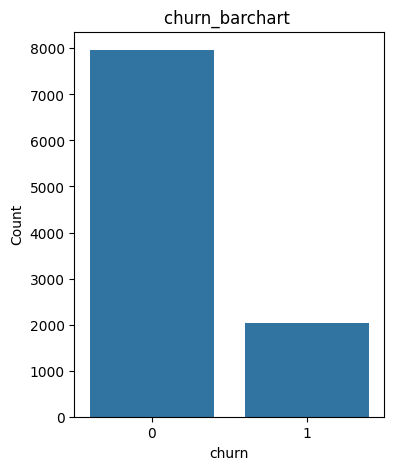

In [51]:
plt.figure(figsize=(4,5))
sns.countplot(x="churn", data=df)
plt.title("churn_barchart ")
plt.xlabel('churn')
plt.ylabel('Count')
plt.show()

# *The dataset is imbalanced because there are  more values in  non-churned customers (0) than churned customers (1)

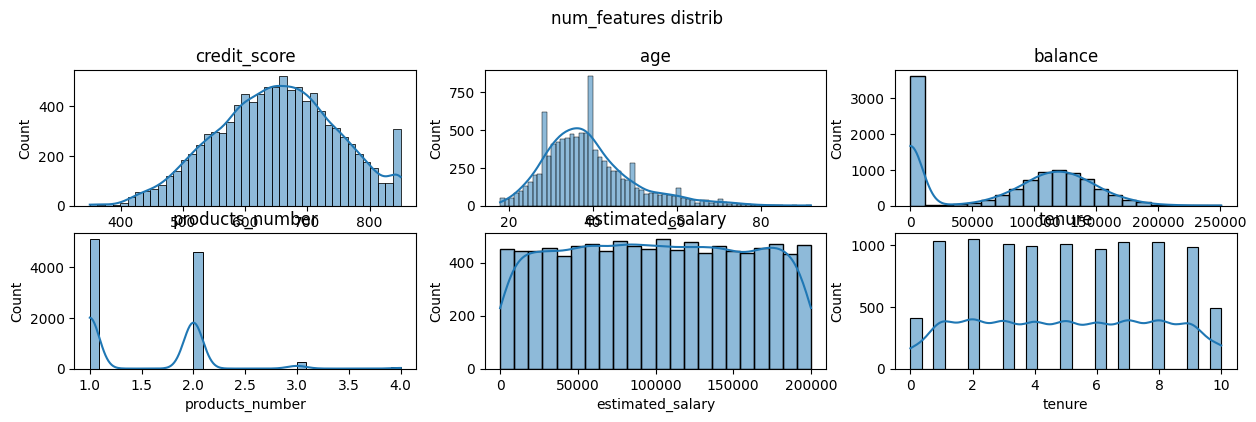

In [63]:
num_col=["credit_score", "age", "balance", "products_number", "estimated_salary", "tenure"]
plt.figure(figsize=(15,6))
for i in range(len(num_col)) :
    plt.subplot(3,3,i+1)
    sns.histplot(x=num_col[i],data=df,kde=True)
    plt.title(num_col[i])
    plt.suptitle("num_features distrib")
plt.show()


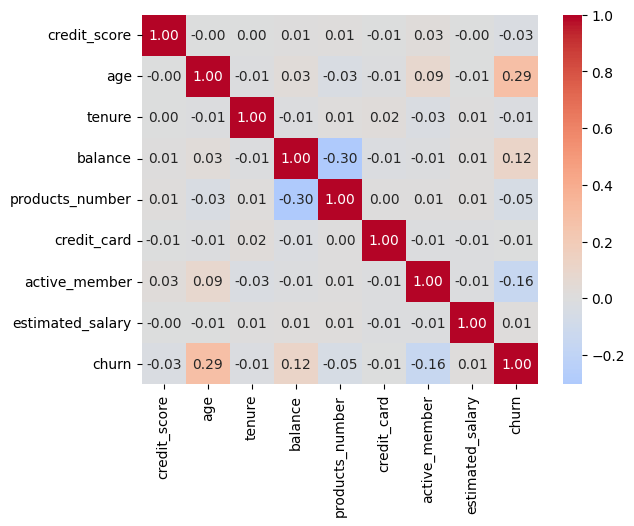

In [20]:
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.show()

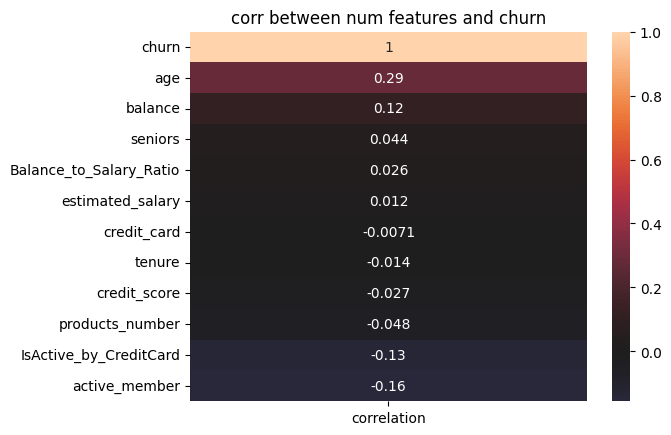

In [65]:
corr = df.select_dtypes(include=np.number).corrwith(df["churn"]).sort_values(ascending=False).to_frame(name="correlation")
sns.heatmap(corr,center=0,annot=True)
plt.title("corr between num features and churn")
plt.show()

In [21]:
df.columns

Index(['credit_score', 'country', 'gender', 'age', 'tenure', 'balance',
       'products_number', 'credit_card', 'active_member', 'estimated_salary',
       'churn'],
      dtype='object')

In [22]:
#Which features correlate positively with Exited? is age, balance , estimated_salary
#Which correlate negatively? is credit_score ,tenure ,products_number, credit_card ,estimated_salary
#Are any input features strongly correlated with each other (multicollinearity)? No there is no strong multicollinearity between the  features

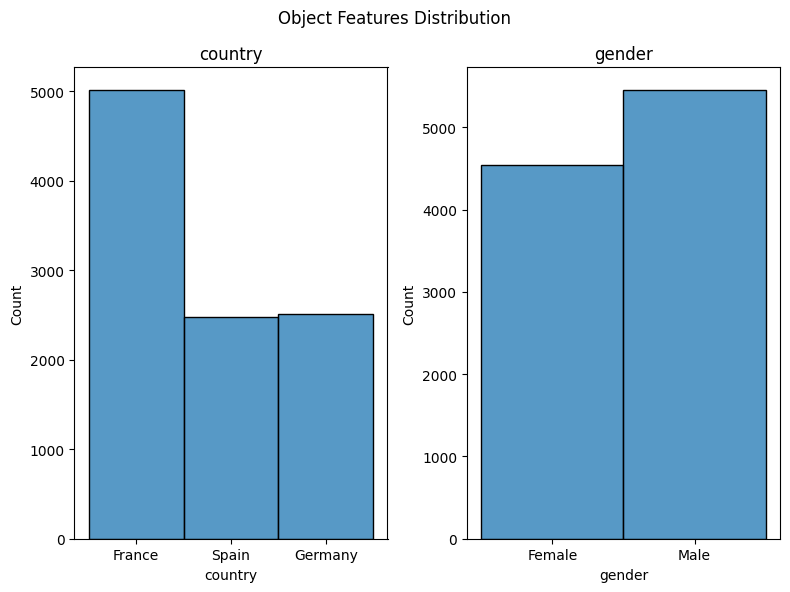

In [79]:
obj_col = df.select_dtypes(include=["object"]).columns

plt.figure(figsize=(8,6))

for i in range(2):
    plt.subplot(1,2,i+1)
    sns.histplot(data=df, x=obj_col[i])
    plt.title(obj_col[i])

plt.suptitle("Object Features Distribution")
plt.tight_layout()
plt.show()

3.6 Write your EDA takeaways
Before moving on, write 3-5 bullet points in a markdown cell:
• Is there class imbalance? How severe? depend on  churn bar plot data is imbalance
• Which features show the strongest individual relationship with churn? see this from correlation map the result is  the strongest one is the age equal 0.29
• Did any distributions or correlations surprise you?There is no strong multicollinearity between the input features
 corr between features (low) also  Estimated Salary has almost no correlation with churn

In [25]:
df["seniors"]=(df["age"]>=60).astype(int)

In [26]:
df["seniors"]
#60 or more =1
#< 60 = 0

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: seniors, Length: 10000, dtype: int64

In [27]:
df["Balance_to_Salary_Ratio"] = (
    df["balance"] /
    df["estimated_salary"]
)

In [28]:
df["IsActive_by_CreditCard"] = (
    df["credit_card"] *
    df["active_member"]
)

In [29]:
df["Geo_Gender"] = (
    df["country"] * 10 +
    df["gender"]
)

In [30]:
x=df.drop("churn",axis=1)
y=df["churn"]

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [33]:
x_train.shape,x_test.shape

((8000, 14), (2000, 14))

In [34]:
y_train.shape,y_test.shape

((8000,), (2000,))

In [35]:
y_train.mean()

np.float64(0.20375)

In [36]:
y_test.mean()

np.float64(0.2035)

In [37]:
from sklearn.preprocessing import LabelEncoder

In [38]:
label_enc_gender=LabelEncoder()
x_train["gender"]=label_enc_gender.fit_transform(x_train["gender"])
x_test["gender"]=label_enc_gender.transform(x_test["gender"])

In [39]:
label_enc_country=LabelEncoder()
x_train["country"]=label_enc_country.fit_transform(x_train["country"])
x_test["country"]=label_enc_country.transform(x_test["country"])

In [40]:
label_enc_geo=LabelEncoder()
x_train["Geo_Gender"]=label_enc_country.fit_transform(x_train["Geo_Gender"])
x_test["Geo_Gender"]=label_enc_country.transform(x_test["Geo_Gender"])

In [41]:
x_train.dtypes

credit_score                 int64
country                      int64
gender                       int64
age                          int64
tenure                       int64
balance                    float64
products_number              int64
credit_card                  int64
active_member                int64
estimated_salary           float64
seniors                      int64
Balance_to_Salary_Ratio    float64
IsActive_by_CreditCard       int64
Geo_Gender                   int64
dtype: object

In [42]:
from xgboost import XGBClassifier

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print(f"Negatives: {neg} | Positives: {pos} | scale_pos_weight: {scale_pos_weight:.2f}")

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb.fit(x_train, y_train)

print("Training complete.")

Negatives: 6370 | Positives: 1630 | scale_pos_weight: 3.91
Training complete.


In [43]:
y_pred = xgb.predict(x_test)
y_prob = xgb.predict_proba(x_test)[:,1]

In [44]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC AUC Score:", roc_auc)


from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

ROC AUC Score: 0.8482781703120685
              precision    recall  f1-score   support

           0       0.91      0.86      0.89      1593
           1       0.56      0.67      0.61       407

    accuracy                           0.82      2000
   macro avg       0.73      0.77      0.75      2000
weighted avg       0.84      0.82      0.83      2000



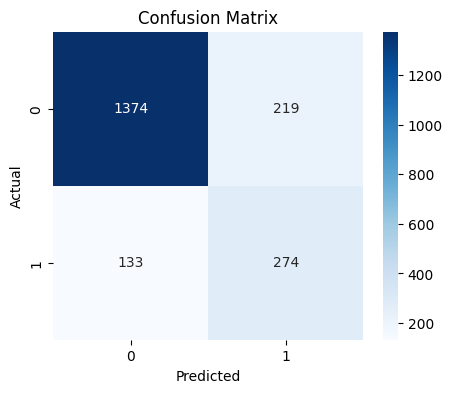

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

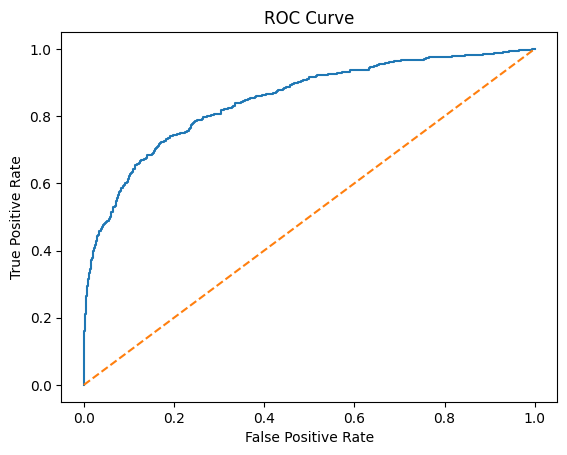

In [46]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

Is the model better at catching churners (recall for class 1) or avoiding false alarms (precision for class1) : from classification repo precision = 0.82
recall = 0.70

Did any engineered feature from Step 4 rank highly?Yes. The engineered feature Balance_to_Salary_Ratio ranked among the most important features.

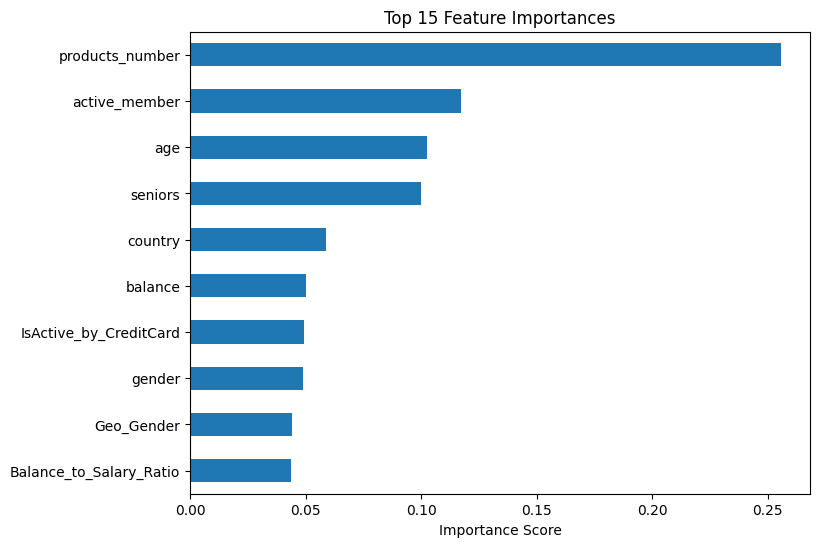

In [86]:
importance = pd.Series(xgb.feature_importances_, index=x_train.columns)
plt.figure(figsize=(16,5))
importance.nlargest(10).sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.show()

In [89]:
!pip install shap

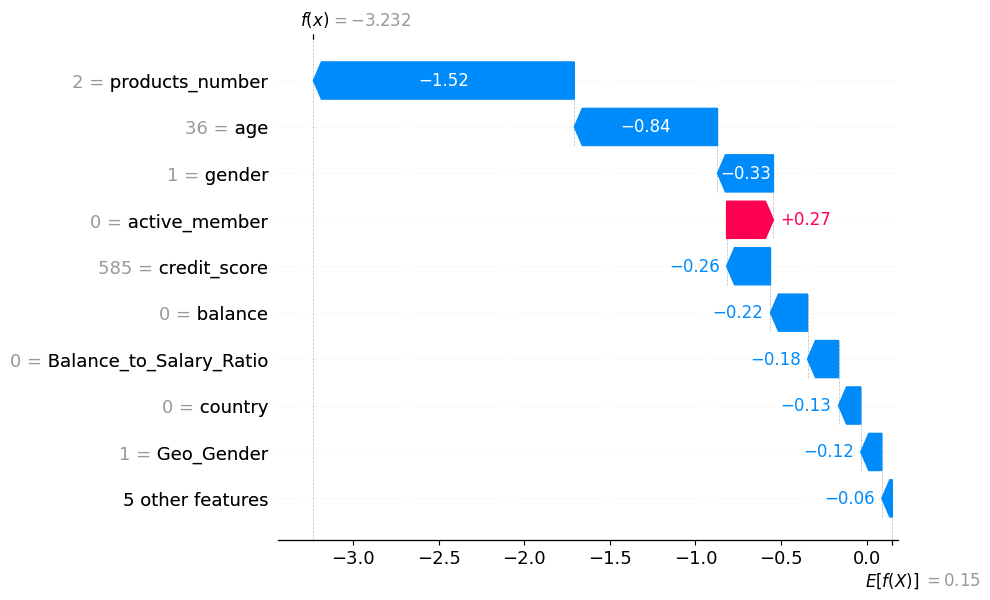

In [92]:
import shap
explainer = shap.Explainer(xgb)
shap_values = explainer(x_test)

shap.plots.waterfall(shap_values[0])

Are there low-importance features you might consider dropping in a second iteration? yess